In [31]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import iirnotch
from scipy.signal import filtfilt
from scipy.signal import butter

In [32]:
diff_data = np.load(
    "../processed/S001_R04_diff.npy"
)

print(diff_data.shape)

(27, 20000)


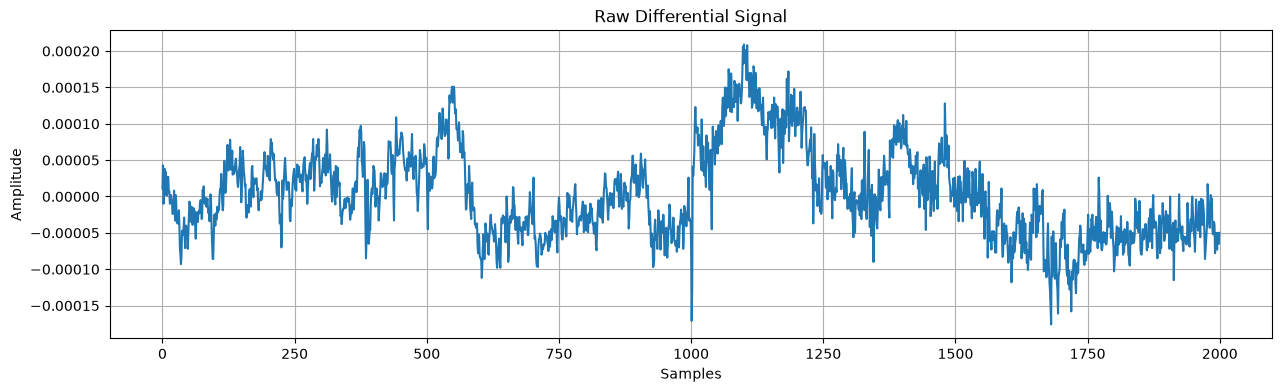

In [33]:
plt.figure(figsize=(15,4))

plt.plot(diff_data[0][:2000])

plt.title("Raw Differential Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.grid()

plt.show()

In [34]:
def apply_notch_filter(data, fs=160, freq=50, Q=30):

    b, a = iirnotch(
        w0=freq,
        Q=Q,
        fs=fs
    )

    filtered = filtfilt(
        b,
        a,
        data,
        axis=1
    )

    return filtered

In [35]:
notch_data = apply_notch_filter(
    diff_data,
    fs=160
)

print(notch_data.shape)

(27, 20000)


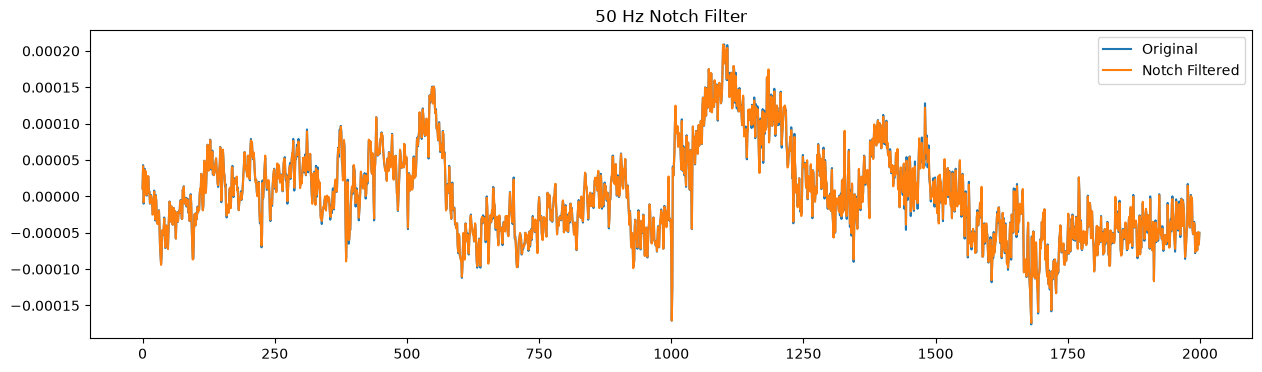

In [36]:
plt.figure(figsize=(15,4))

plt.plot(
    diff_data[0][:2000],
    label="Original"
)

plt.plot(
    notch_data[0][:2000],
    label="Notch Filtered"
)

plt.legend()

plt.title("50 Hz Notch Filter")

plt.show()

In [37]:
def apply_bandpass_filter(
    data,
    fs=160,
    lowcut=0.5,
    highcut=70,
    order=4
):

    nyquist = fs / 2

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(
        order,
        [low, high],
        btype='band'
    )

    filtered = filtfilt(
        b,
        a,
        data,
        axis=1
    )

    return filtered

In [38]:
filtered_data = apply_bandpass_filter(
    notch_data,
    fs=160
)

print(filtered_data.shape)

(27, 20000)


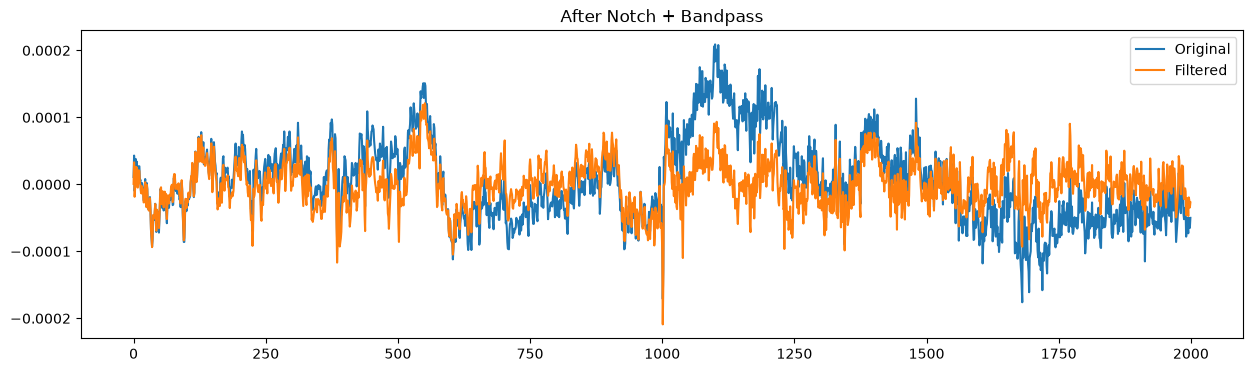

In [39]:
plt.figure(figsize=(15,4))

plt.plot(
    diff_data[0][:2000],
    label="Original"
)

plt.plot(
    filtered_data[0][:2000],
    label="Filtered"
)

plt.legend()

plt.title("After Notch + Bandpass")

plt.show()

In [40]:
def minmax_normalize(data):

    data_min = np.min(
        data,
        axis=1,
        keepdims=True
    )

    data_max = np.max(
        data,
        axis=1,
        keepdims=True
    )

    normalized = (
        data - data_min
    ) / (
        data_max - data_min
    )

    return normalized

In [41]:
normalized_data = minmax_normalize(
    filtered_data
)

print(normalized_data.shape)

(27, 20000)


In [42]:
print("Min:", np.min(normalized_data))
print("Max:", np.max(normalized_data))

Min: 0.0
Max: 1.0


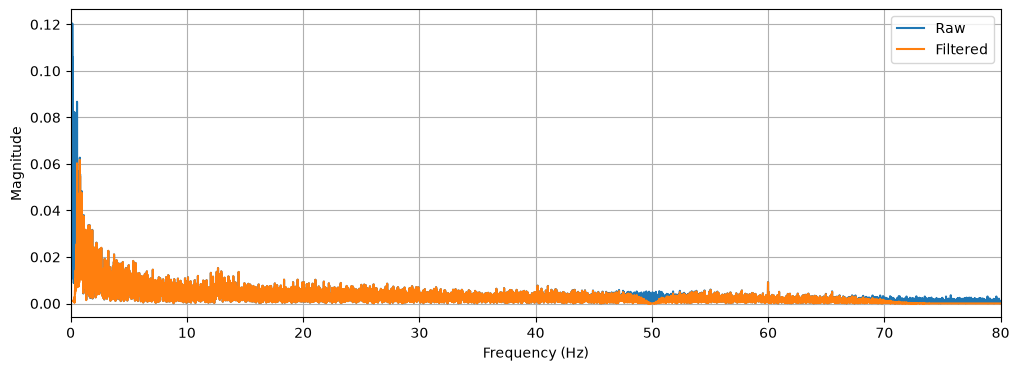

In [43]:
fs = 160

plt.figure(figsize=(12,4))

freqs = np.fft.rfftfreq(len(diff_data[0]), d=1/fs)

raw_fft = np.abs(np.fft.rfft(diff_data[0]))
filtered_fft = np.abs(np.fft.rfft(filtered_data[0]))

plt.plot(freqs, raw_fft, label='Raw')
plt.plot(freqs, filtered_fft, label='Filtered')

plt.xlim(0,80)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid()

plt.show()

In [44]:
print("Raw")
print(np.min(diff_data))
print(np.max(diff_data))
print(np.std(diff_data))

print("\nFiltered")
print(np.min(filtered_data))
print(np.max(filtered_data))
print(np.std(filtered_data))

Raw
-0.000325
0.000332
3.866406504971133e-05

Filtered
-0.00031010761021664106
0.00024307916931780754
2.8219422454345623e-05


In [45]:
np.save("../processed/S001_R04_filtered.npy",
        filtered_data)

np.save("../processed/S001_R04_preprocessed.npy",
        normalized_data)